# 2. The wavegram, and signals longer than the window

Every wavelet coefficient is a tile in time and frequency. Drawing them all is
the trigger's *wavegram*, and it is what the search already computed -- no
second transform, no spectrogram of anything.

This notebook reads parameters off the wavegram, then uses it to decide which
analysis windows belong to the same transient, which is what a signal longer
than one window needs. As in notebook 1, everything is made here.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pytsa.tsa import WaveletTransform
from wdf.structures.array2SeqView import array2SeqView
from wdf.mock import waveforms as w
from wdf.analysis.wavelets import donoho_johnstone_threshold

FS, WINDOW, OVERLAP, SIGMA = 2048.0, 512, 128, 1.0
STEP = WINDOW - OVERLAP
WAVE = "Sym8"


def forward(samples, wave=WAVE):
    view = array2SeqView(0.0, FS, len(samples))
    view = view.Fill(0.0, np.asarray(samples, dtype=float).copy())
    WaveletTransform(len(samples), getattr(WaveletTransform, wave)).Forward(view)
    return np.array([view.GetY(0, i) for i in range(len(samples))])


def thresholded(samples):
    c = forward(samples)
    return np.where(np.abs(c) >= donoho_johnstone_threshold(SIGMA, len(c)), c, 0.0)

## One window holding a chirp

A signal that sweeps in frequency is the case where the two ways of asking "what
frequency is this?" disagree.

In [2]:
chirp = w.chirplike(60.0, 500.0, WINDOW / FS, int(FS))
x = np.zeros(WINDOW)
n = min(len(chirp), WINDOW)
x[:n] = chirp[:n] / np.linalg.norm(chirp[:n]) * 25.0

kept = thresholded(x)
print(f"{np.count_nonzero(kept)} surviving coefficients")

18 surviving coefficients


In [3]:
from wdf.analysis.wavelets import dominant_tile, wavegram_ridge, plot_wavelet_tiles

tile = dominant_tile(kept, FS, sigma=SIGMA)
ridge = wavegram_ridge(kept, FS, sigma=SIGMA, n_time_bins=24)

spectrum = np.abs(np.fft.rfft((x - x.mean()) * np.hanning(WINDOW))) ** 2
periodogram_peak = np.fft.rfftfreq(WINDOW, 1.0 / FS)[int(np.argmax(spectrum))]

print(f"loudest tile      {tile['freq']:6.1f} Hz  (band {tile['f_lo']:.0f}-{tile['f_hi']:.0f} Hz,"
      f" tile SNR {tile['snr']:.1f})")
print(f"periodogram peak  {periodogram_peak:6.1f} Hz")

loudest tile       181.0 Hz  (band 128-256 Hz, tile SNR 5.1)
periodogram peak   280.0 Hz


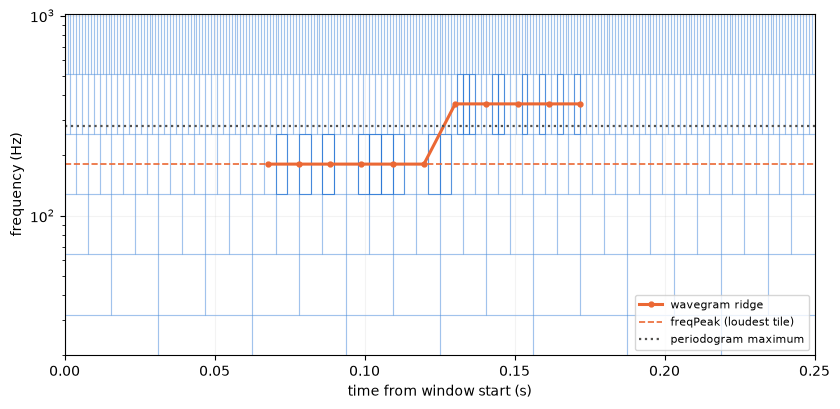

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))

plot_wavelet_tiles(ax, kept, FS, top_frac=1.0, edgecolor="#2a78d6", lw=0.8)

present = np.isfinite(ridge["freqs"])
ax.plot(ridge["times"][present], ridge["freqs"][present], color="#eb6834", lw=2.2,
        marker="o", ms=3.5, label="wavegram ridge")
ax.axhline(tile["freq"], color="#eb6834", ls="--", lw=1.2, label="freqPeak (loudest tile)")
ax.axhline(periodogram_peak, color="#52514e", ls=":", lw=1.6, label="periodogram maximum")

ax.set_yscale("log")
ax.set_ylim(20, FS / 2)
ax.set_xlim(0, WINDOW / FS)
ax.set_xlabel("time from window start (s)")
ax.set_ylabel("frequency (Hz)")
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.15)
fig.tight_layout()
plt.show()

The ridge follows the sweep. `freqPeak` sits on its loudest point; the
periodogram maximum sits somewhere else entirely, because it answers a question
about integrated energy rather than about amplitude.

Note the tile shapes: wide in time and narrow in frequency at the bottom, the
reverse at the top. That is the resolution trade the transform makes, and it is
why `freqPeak` has octave resolution.

## A signal longer than the window

WDF steps by `window - overlap` samples, so consecutive windows each hold a
different piece of a long signal and each scores only its own piece. Here is a
chirp spanning seven windows, turned into the per-window triggers the search
would emit.

In [5]:
length = WINDOW + 6 * STEP
envelope = np.hanning(length)
phase = 2 * np.pi * np.cumsum(np.linspace(80.0, 300.0, length)) / FS
long_signal = 6.0 * envelope * np.sin(phase)

rows = []
for first in range(0, length - WINDOW + 1, STEP):
    coefficients = thresholded(long_signal[first:first + WINDOW])
    row = dict(gps=1000.0 + first / FS, gpsPeak=1000.0 + first / FS, ifo="H1",
               wave=WAVE, sigma=SIGMA,
               EnWDF=float(np.linalg.norm(coefficients) / SIGMA))
    row.update({f"wt{i}": v for i, v in enumerate(coefficients)})
    rows.append(row)

TRIGGERS = pd.DataFrame(rows)
print(f"{len(TRIGGERS)} triggers")
print(f"loudest single window: EnWDF = {TRIGGERS.EnWDF.max():.1f}")
print(f"whole signal:          rho   = {np.linalg.norm(long_signal) / SIGMA:.1f}")

7 triggers
loudest single window: EnWDF = 90.7
whole signal:          rho   = 137.8


The loudest window carries only a fraction of what the signal is worth. The
recovery is a two-step operation:

1. **Percolation on the wavegram** decides which windows belong together. Every
   surviving coefficient becomes a tile in absolute time; tiles whose bands
   overlap and whose time supports are close are chained into one component.
2. **The stitched reconstruction** decides how loud the event is. Each trigger
   contributes the step region of its own window, so the pieces tile the span
   exactly once and no sample is counted twice.

`wavegram_events` does both.

In [6]:
from wdf.analysis.clustering import wavegram_events

EVENTS = wavegram_events(TRIGGERS, FS, WINDOW, OVERLAP, time_tol_s=0.05)
print(EVENTS[["cluster_id", "gpsStart", "gpsEnd", "freqMin", "freqPeak", "freqMax",
              "windows", "loudest_window", "EnWDF"]].to_string(index=False))

 cluster_id  gpsStart      gpsEnd  freqMin   freqPeak  freqMax  windows  loudest_window      EnWDF
          0 1000.1875 1001.046875     64.0 181.019336    512.0        6       90.682315 130.630898


`EnWDF` here is the norm of the reconstruction over the signal's whole extent
divided by the noise scale -- the same definition as for one window, measured
over more of the signal. `loudest_window` is kept alongside it so the gain is
visible rather than asserted.

Summing the energy of the pixels instead would *overcount*: consecutive windows
overlap, so a pixel covering a given sample appears once per window that
contains it. `WaveletPixelClusterer.clustered_events` reports that sum too, as
an upper bound and a diagnostic, but the reconstruction is the value to release.

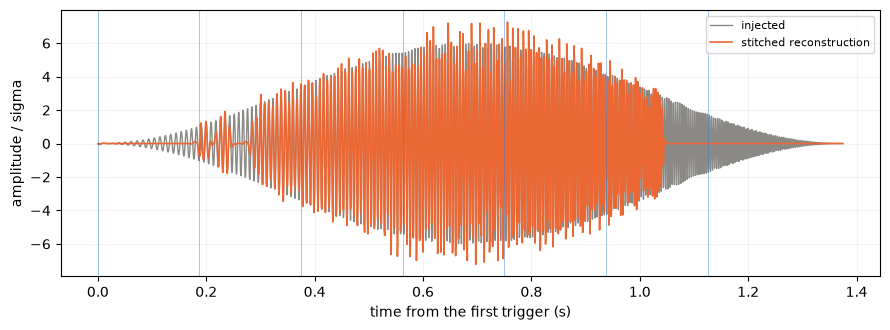

In [7]:
from wdf.analysis.reconstruction import stitch

gps_start, stitched = stitch(TRIGGERS, FS, WINDOW, OVERLAP)

fig, ax = plt.subplots(figsize=(9, 3.4))
t_true = np.arange(length) / FS
ax.plot(t_true, long_signal, lw=1.0, color="#8a8985", label="injected")
ax.plot(np.arange(stitched.size) / FS, stitched, lw=1.2, color="#eb6834",
        label="stitched reconstruction")
for first in range(0, length - WINDOW + 1, STEP):
    ax.axvline(first / FS, color="#2a78d6", lw=0.6, alpha=0.5)
ax.set_xlabel("time from the first trigger (s)")
ax.set_ylabel("amplitude / sigma")
ax.legend(fontsize=8)
ax.grid(alpha=0.15)
fig.tight_layout()
plt.show()